In [2]:
import numpy as np
import matplotlib.pyplot as plt
import re

import nltk
from nltk.corpus import gutenberg

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.utils import to_categorical

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
nltk.download('gutenberg')

print("Gutenberg corpus downloaded!")

Gutenberg corpus downloaded!


[nltk_data] Downloading package gutenberg to /root/nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!


In [4]:
# Load Shakespeare's Hamlet
words = gutenberg.words('shakespeare-hamlet.txt')

# Complete text
text = gutenberg.raw('shakespeare-hamlet.txt')

print("Dataset loaded successfully!")
print("Number of tokens:", len(words))

Dataset loaded successfully!
Number of tokens: 37360


In [5]:
total_words = len(words)

print("Total number of words:", total_words)

Total number of words: 37360


In [6]:
lines = text.splitlines()

print("First 10 lines of Hamlet:\n")

for i, line in enumerate(lines[:10], start=1):
    print(f"{i}: {line}")

First 10 lines of Hamlet:

1: [The Tragedie of Hamlet by William Shakespeare 1599]
2: 
3: 
4: Actus Primus. Scoena Prima.
5: 
6: Enter Barnardo and Francisco two Centinels.
7: 
8:   Barnardo. Who's there?
9:   Fran. Nay answer me: Stand & vnfold
10: your selfe


In [7]:
## Task 1: Data Collection & Understanding

print("The Shakespeare Hamlet dataset is suitable for language modeling because it contains a large amount of naturally occurring English text with meaningful sentence structures, vocabulary, grammar, and contextual relationships between words. A language model can learn these patterns and use the previous words to predict the next word.")

The Shakespeare Hamlet dataset is suitable for language modeling because it contains a large amount of naturally occurring English text with meaningful sentence structures, vocabulary, grammar, and contextual relationships between words. A language model can learn these patterns and use the previous words to predict the next word.


In [8]:
# Convert text to lowercase
clean_text = text.lower()

# Keep alphabets and spaces
clean_text = re.sub(r'[^a-z\s]', ' ', clean_text)

# Remove extra spaces
clean_text = re.sub(r'\s+', ' ', clean_text).strip()

print(clean_text[:1000])

the tragedie of hamlet by william shakespeare actus primus scoena prima enter barnardo and francisco two centinels barnardo who s there fran nay answer me stand vnfold your selfe bar long liue the king fran barnardo bar he fran you come most carefully vpon your houre bar tis now strook twelue get thee to bed francisco fran for this releefe much thankes tis bitter cold and i am sicke at heart barn haue you had quiet guard fran not a mouse stirring barn well goodnight if you do meet horatio and marcellus the riuals of my watch bid them make hast enter horatio and marcellus fran i thinke i heare them stand who s there hor friends to this ground mar and leige men to the dane fran giue you good night mar o farwel honest soldier who hath relieu d you fra barnardo ha s my place giue you goodnight exit fran mar holla barnardo bar say what is horatio there hor a peece of him bar welcome horatio welcome good marcellus mar what ha s this thing appear d againe to night bar i haue seene nothing mar

In [9]:
tokenizer = Tokenizer()

# Tokenize the cleaned text
tokenizer.fit_on_texts([clean_text])

word_index = tokenizer.word_index

print("Vocabulary size:", len(word_index))
print("\nFirst 20 words from word index:")

for word, index in list(word_index.items())[:20]:
    print(word, ":", index)

Vocabulary size: 4699

First 20 words from word index:
the : 1
and : 2
to : 3
of : 4
i : 5
you : 6
a : 7
my : 8
it : 9
in : 10
that : 11
ham : 12
is : 13
not : 14
his : 15
this : 16
with : 17
your : 18
but : 19
for : 20


In [10]:
print("Word Index Dictionary:")
print(word_index)

Word Index Dictionary:
{'the': 1, 'and': 2, 'to': 3, 'of': 4, 'i': 5, 'you': 6, 'a': 7, 'my': 8, 'it': 9, 'in': 10, 'that': 11, 'ham': 12, 'is': 13, 'not': 14, 'his': 15, 'this': 16, 'with': 17, 'your': 18, 'but': 19, 'for': 20, 'me': 21, 'd': 22, 'what': 23, 'lord': 24, 'as': 25, 'he': 26, 'be': 27, 'so': 28, 'haue': 29, 'him': 30, 'king': 31, 'will': 32, 'no': 33, 'on': 34, 'our': 35, 'we': 36, 's': 37, 'are': 38, 'if': 39, 'all': 40, 'then': 41, 'by': 42, 'thou': 43, 'shall': 44, 'come': 45, 'do': 46, 'let': 47, 'or': 48, 'hamlet': 49, 'good': 50, 'hor': 51, 'her': 52, 'there': 53, 'now': 54, 't': 55, 'thy': 56, 'they': 57, 'how': 58, 'more': 59, 'from': 60, 'enter': 61, 'was': 62, 'at': 63, 'oh': 64, 'like': 65, 'most': 66, 'would': 67, 'well': 68, 'know': 69, 'tis': 70, 'selfe': 71, 'them': 72, 'o': 73, 'loue': 74, 'may': 75, 'vs': 76, 'did': 77, 'th': 78, 'sir': 79, 'qu': 80, 'too': 81, 'which': 82, 'why': 83, 'laer': 84, 'giue': 85, 'thee': 86, 'ile': 87, 'must': 88, 'hath': 89,

In [11]:
## Importance of Tokenization in NLP

print("Tokenization converts text into smaller units called tokens, such as words. Neural networks cannot directly process raw text, so tokenization allows each word to be represented by a numerical index. This numerical representation can then be used by deep learning models for language modeling and next-word prediction.")

Tokenization converts text into smaller units called tokens, such as words. Neural networks cannot directly process raw text, so tokenization allows each word to be represented by a numerical index. This numerical representation can then be used by deep learning models for language modeling and next-word prediction.


In [12]:
tokenized_text = tokenizer.texts_to_sequences([clean_text])[0]

print("First 50 numerical tokens:")
print(tokenized_text[:50])

First 50 numerical tokens:
[1, 686, 4, 49, 42, 1852, 1853, 1173, 1854, 1855, 1856, 61, 407, 2, 1174, 184, 1857, 407, 124, 37, 53, 408, 167, 376, 21, 252, 876, 18, 71, 454, 230, 253, 1, 31, 408, 407, 454, 26, 408, 6, 45, 66, 1858, 97, 18, 563, 454, 70, 54, 1859]


In [13]:
# Maximum number of words in each training sequence
max_words = 20

input_sequences = []

for i in range(1, len(tokenized_text)):
    start = max(0, i - max_words + 1)
    sequence = tokenized_text[start:i+1]
    input_sequences.append(sequence)

print("Total sequences generated:", len(input_sequences))
print("First 10 sequences:")

for seq in input_sequences[:10]:
    print(seq)

Total sequences generated: 30265
First 10 sequences:
[1, 686]
[1, 686, 4]
[1, 686, 4, 49]
[1, 686, 4, 49, 42]
[1, 686, 4, 49, 42, 1852]
[1, 686, 4, 49, 42, 1852, 1853]
[1, 686, 4, 49, 42, 1852, 1853, 1173]
[1, 686, 4, 49, 42, 1852, 1853, 1173, 1854]
[1, 686, 4, 49, 42, 1852, 1853, 1173, 1854, 1855]
[1, 686, 4, 49, 42, 1852, 1853, 1173, 1854, 1855, 1856]


In [14]:
max_sequence_length = max(len(seq) for seq in input_sequences)

padded_sequences = pad_sequences(
    input_sequences,
    maxlen=max_sequence_length,
    padding='pre'
)

print("Maximum sequence length:", max_sequence_length)
print("Padded sequences shape:", padded_sequences.shape)

Maximum sequence length: 20
Padded sequences shape: (30265, 20)


In [15]:
X = padded_sequences[:, :-1]
y = padded_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (30265, 19)
y shape: (30265,)


In [16]:
vocab_size = len(tokenizer.word_index) + 1

print("Vocabulary size:", vocab_size)
print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 4700
X shape: (30265, 19)
y shape: (30265,)


In [17]:
## Why Padding is Required?

print("Sequences generated from text can have different lengths. Padding makes all sequences the same length so that they can be processed efficiently by a neural network. In this implementation, sequences are padded at the beginning using pre-padding.")

Sequences generated from text can have different lengths. Padding makes all sequences the same length so that they can be processed efficiently by a neural network. In this implementation, sequences are padded at the beginning using pre-padding.


In [18]:
embedding_dim = 100
lstm_units = 128

model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim
    ),

    LSTM(lstm_units),

    Dense(vocab_size, activation='softmax')
])

print("LSTM model created successfully!")

LSTM model created successfully!


In [19]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [21]:
epochs = 10
batch_size = 128

history = model.fit(
    X,
    y,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 26s 111ms/step - accuracy: 0.0296 - loss: 6.8656 - val_accuracy: 0.0413 - val_loss: 6.6400
Epoch 2/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 22s 104ms/step - accuracy: 0.0370 - loss: 6.4169 - val_accuracy: 0.0311 - val_loss: 6.7270
Epoch 3/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 22s 103ms/step - accuracy: 0.0407 - loss: 6.3261 - val_accuracy: 0.0433 - val_loss: 6.7697
Epoch 4/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 24s 113ms/step - accuracy: 0.0515 - loss: 6.2209 - val_accuracy: 0.0472 - val_loss: 6.7777
Epoch 5/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 24s 111ms/step - accuracy: 0.0560 - loss: 6.1155 - val_accuracy: 0.0499 - val_loss: 6.7810
Epoch 6/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 40s 106ms/step - accuracy: 0.0619 - loss: 6.0210 - val_accuracy: 0.0532 - val_loss: 6.7949
Epoch 7/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 44s 117ms/step - accuracy: 0.0695 - loss: 5.9292 - val_accuracy: 0.0572 - val_loss: 6.8283
Epoch 8/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 22s 105ms/step - accuracy: 0.0756 - loss: 5

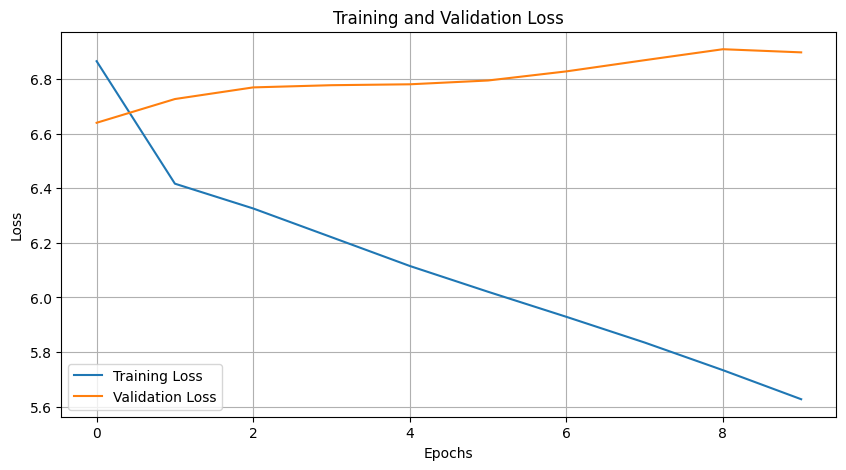

In [22]:
plt.figure(figsize=(10, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.show()

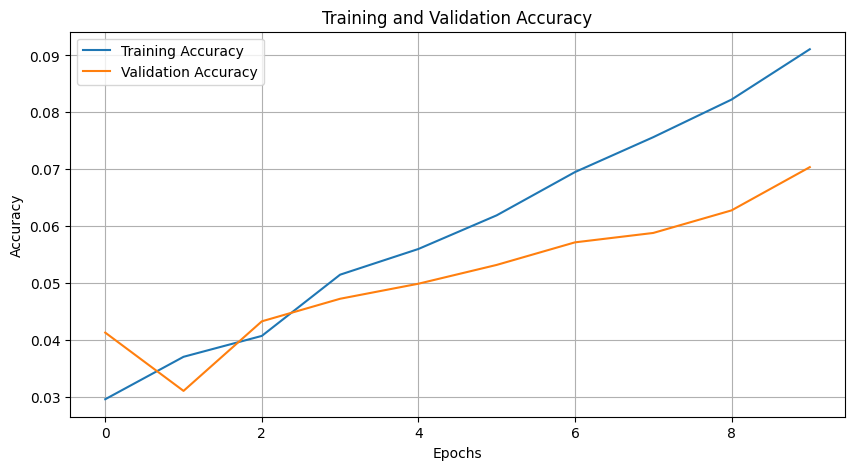

In [23]:
plt.figure(figsize=(10, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.show()

In [24]:
loss, accuracy = model.evaluate(
    X,
    y,
    verbose=0
)

print("Model Evaluation")
print("-------------------------")
print("Loss:", loss)
print("Accuracy:", accuracy)

Model Evaluation
-------------------------
Loss: 5.617805004119873
Accuracy: 0.09707582741975784


In [26]:
## Overfitting / Underfitting Analysis

print("The training and validation loss curves are used to analyze the model's learning behavior.")

print("If the training loss continues to decrease while validation loss starts increasing, it indicates overfitting. If both training and validation losses remain high, the model may be underfitting.")

print("The training and validation curves obtained above should be examined to determine whether the model shows signs of overfitting or underfitting.")

The training and validation loss curves are used to analyze the model's learning behavior.
If the training loss continues to decrease while validation loss starts increasing, it indicates overfitting. If both training and validation losses remain high, the model may be underfitting.
The training and validation curves obtained above should be examined to determine whether the model shows signs of overfitting or underfitting.


In [27]:
def predict_next_word(seed_text):
    seed_text = seed_text.lower()

    # Convert seed text into numerical sequence
    token_list = tokenizer.texts_to_sequences([seed_text])[0]

    # Check if words exist in vocabulary
    if len(token_list) == 0:
        return "Unknown word(s)"

    # Keep only the last required words
    token_list = token_list[-X.shape[1]:]

    # Pad the sequence
    token_list = pad_sequences(
        [token_list],
        maxlen=X.shape[1],
        padding='pre'
    )

    # Predict probabilities
    predicted_probabilities = model.predict(
        token_list,
        verbose=0
    )

    # Get index of word with highest probability
    predicted_index = np.argmax(
        predicted_probabilities,
        axis=-1
    )[0]

    # Convert index back to word
    predicted_word = tokenizer.index_word.get(
        predicted_index,
        "Unknown"
    )

    return predicted_word

In [28]:
seed_text = "to be"

prediction = predict_next_word(seed_text)

print("Seed text:", seed_text)
print("Predicted next word:", prediction)

Seed text: to be
Predicted next word: not


In [29]:
seed_text = "what is"

prediction = predict_next_word(seed_text)

print("Seed text:", seed_text)
print("Predicted next word:", prediction)

Seed text: what is
Predicted next word: the


In [30]:
seed_text = "my lord"

prediction = predict_next_word(seed_text)

print("Seed text:", seed_text)
print("Predicted next word:", prediction)

Seed text: my lord
Predicted next word: ham


In [31]:
seed_text = "the king"

prediction = predict_next_word(seed_text)

print("Seed text:", seed_text)
print("Predicted next word:", prediction)

Seed text: the king
Predicted next word: and


In [32]:
seed_text = "good night"

prediction = predict_next_word(seed_text)

print("Seed text:", seed_text)
print("Predicted next word:", prediction)

Seed text: good night
Predicted next word: and


In [33]:
test_inputs = [
    "to be",
    "what is",
    "my lord",
    "the king",
    "good night"
]

print("Next Word Prediction Results")
print("=" * 50)

for seed in test_inputs:
    predicted = predict_next_word(seed)

    print(f"Input: {seed}")
    print(f"Predicted Next Word: {predicted}")
    print("-" * 50)

Next Word Prediction Results
Input: to be
Predicted Next Word: not
--------------------------------------------------
Input: what is
Predicted Next Word: the
--------------------------------------------------
Input: my lord
Predicted Next Word: ham
--------------------------------------------------
Input: the king
Predicted Next Word: and
--------------------------------------------------
Input: good night
Predicted Next Word: and
--------------------------------------------------


In [34]:
# Task 8: Analysis & Improvements

In [36]:
from tkinter import N
## 1. Limitations of LSTM in Language Modeling

print("LSTM networks are capable of learning sequential dependencies, but they have several limitations:")

print("1. LSTMs process sequences sequentially, which can make training slower.")
print("2. They are less parallelizable than Transformer architectures.")
print("3. Very long sequences can still be difficult to model efficiently.")
print("4. LSTM models can require considerable computational resources.")
print("5. Performance depends on the quantity and quality of training data.")

LSTM networks are capable of learning sequential dependencies, but they have several limitations:
1. LSTMs process sequences sequentially, which can make training slower.
2. They are less parallelizable than Transformer architectures.
3. Very long sequences can still be difficult to model efficiently.
4. LSTM models can require considerable computational resources.
5. Performance depends on the quantity and quality of training data.


In [37]:
print("""
2. How Can Performance Be Improved?

The performance of the next-word prediction model can be improved by:

1. Using a larger and more diverse dataset.
2. Improving the quality of text preprocessing.
3. Tuning hyperparameters such as learning rate, batch size, embedding dimension and number of LSTM units.
4. Using regularization techniques such as dropout to reduce overfitting.
5. Using Bidirectional LSTM where appropriate.
6. Using deeper or more suitable neural network architectures.
7. Using Transformer-based architectures for better contextual modeling.
""")


2. How Can Performance Be Improved?

The performance of the next-word prediction model can be improved by:

1. Using a larger and more diverse dataset.
2. Improving the quality of text preprocessing.
3. Tuning hyperparameters such as learning rate, batch size, embedding dimension and number of LSTM units.
4. Using regularization techniques such as dropout to reduce overfitting.
5. Using Bidirectional LSTM where appropriate.
6. Using deeper or more suitable neural network architectures.
7. Using Transformer-based architectures for better contextual modeling.



In [38]:
print("""
3. LSTM vs Transformer Architecture

LSTM:
- Uses a recurrent neural network architecture.
- Processes sequences sequentially.
- Uses hidden states and memory to maintain contextual information.
- Has limited parallelization.
- Can be slower for large-scale language modeling.

Transformer:
- Uses an attention-based architecture.
- Uses self-attention to model relationships between tokens.
- Allows highly parallelized processing during training.
- Handles long-range contextual relationships effectively.
- Is widely used for modern large-scale language modeling.

Overall, LSTMs are useful for sequential modeling, while Transformers are generally more suitable for large-scale language modeling because of their parallelization and self-attention mechanism.
""")


3. LSTM vs Transformer Architecture

LSTM:
- Uses a recurrent neural network architecture.
- Processes sequences sequentially.
- Uses hidden states and memory to maintain contextual information.
- Has limited parallelization.
- Can be slower for large-scale language modeling.

Transformer:
- Uses an attention-based architecture.
- Uses self-attention to model relationships between tokens.
- Allows highly parallelized processing during training.
- Handles long-range contextual relationships effectively.
- Is widely used for modern large-scale language modeling.

Overall, LSTMs are useful for sequential modeling, while Transformers are generally more suitable for large-scale language modeling because of their parallelization and self-attention mechanism.



In [39]:
print("""
FINAL OBSERVATIONS

The Shakespeare Hamlet dataset from the NLTK Gutenberg Corpus was used to build a next-word prediction system.

The text was converted to lowercase and unnecessary characters were removed. Keras Tokenizer was then used to convert words into numerical representations.

N-gram sequences were generated from the tokenized text. The sequences were padded to obtain a common input length, after which predictors (X) and labels (y) were separated.

An LSTM-based neural network containing an Embedding layer, LSTM layer and Dense Softmax output layer was implemented. The model was trained using the Adam optimizer and sparse categorical crossentropy loss.

The model was evaluated using loss and accuracy, and training/validation curves were plotted. A next-word prediction function was also implemented and tested using five different seed texts.
""")


FINAL OBSERVATIONS

The Shakespeare Hamlet dataset from the NLTK Gutenberg Corpus was used to build a next-word prediction system.

The text was converted to lowercase and unnecessary characters were removed. Keras Tokenizer was then used to convert words into numerical representations.

N-gram sequences were generated from the tokenized text. The sequences were padded to obtain a common input length, after which predictors (X) and labels (y) were separated.

An LSTM-based neural network containing an Embedding layer, LSTM layer and Dense Softmax output layer was implemented. The model was trained using the Adam optimizer and sparse categorical crossentropy loss.

The model was evaluated using loss and accuracy, and training/validation curves were plotted. A next-word prediction function was also implemented and tested using five different seed texts.



In [40]:
print("""
CONCLUSION

This assignment demonstrated the complete workflow for building a next-word prediction system using deep learning.

The process included data collection, text preprocessing, tokenization, sequence generation, padding, feature and label creation, LSTM model development, training, evaluation and next-word prediction.

The experiment demonstrates how recurrent neural networks can learn patterns from sequential text and use previously observed words to predict a possible next word.

LSTM provides a useful approach for sequential language modeling, while modern Transformer architectures can provide improved scalability, parallelization and contextual understanding for larger language-modeling tasks.
""")


CONCLUSION

This assignment demonstrated the complete workflow for building a next-word prediction system using deep learning.

The process included data collection, text preprocessing, tokenization, sequence generation, padding, feature and label creation, LSTM model development, training, evaluation and next-word prediction.

The experiment demonstrates how recurrent neural networks can learn patterns from sequential text and use previously observed words to predict a possible next word.

LSTM provides a useful approach for sequential language modeling, while modern Transformer architectures can provide improved scalability, parallelization and contextual understanding for larger language-modeling tasks.

